In [1]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================

# Data Manipulation
import pandas as pd
import numpy as np
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Utility
import io
from pathlib import Path

# Suppress warnings untuk tampilan yang lebih bersih
warnings.filterwarnings('ignore')

# ==========================================
# 2. KONFIGURASI VISUALISASI
# ==========================================

# Set style seaborn yang lebih profesional
sns.set_theme(style="whitegrid", palette="husl")

# Konfigurasi matplotlib
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 10

# Display settings untuk pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.precision', 2)

print("✅ Libraries berhasil dimuat!")
print("✅ Konfigurasi visualisasi telah diatur!\n")

✅ Libraries berhasil dimuat!
✅ Konfigurasi visualisasi telah diatur!



In [ ]:
"""
===================================================================================
KODE INTEGRASI & ANALISIS DATA ENERGI (FULL VERSION)
Metodologi: Integrasi Data -> EDA -> Feature Engineering -> Modeling -> Evaluasi
===================================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import traceback
import joblib # Untuk menyimpan model

# Import scikit-learn & statsmodels
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')

# Konfigurasi Plot
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*80)
print("TAHAP 1: PENGUMPULAN & INTEGRASI DATA")
print("="*80)

# ===========================
# BAGIAN 1: DEFINISI FILE
# ===========================
print("\n[1/5] Mendefinisikan file energi dan cuaca...")

# ✅ DAFTAR FILE LENGKAP DENGAN PATH YANG BENAR (FORWARD SLASH)
file_energi_list = [
    # --- Gedung OPMC (13 File) ---
    'smart_meter_labeling\smart_meter_labeling\Gedung_OPMC_Panel_Distribusi_SDP\OPMC_SDP_L1.csv',
    'smart_meter_labeling\smart_meter_labeling\Gedung_OPMC_Panel_Distribusi_SDP\OPMC_SDP_L2.csv',
    'smart_meter_labeling\smart_meter_labeling\Gedung_OPMC_Panel_Distribusi_SDP\OPMC_SDP_L3.csv',
    'smart_meter_labeling\smart_meter_labeling\Gedung_OPMC_Panel_Distribusi_SDP\OPMC_SDP_L4.csv',
    'smart_meter_labeling\smart_meter_labeling\Gedung_OPMC_Panel_Distribusi_SDP\OPMC_SDP_L5.csv',
    'smart_meter_labeling\smart_meter_labeling\Gedung_OPMC_Panel_Distribusi_SDP\OPMC_SDP_L6.csv',
    'smart_meter_labeling\smart_meter_labeling\Gedung_OPMC_Pendingin_Udara_AHU\OPMC_AHU_L2.csv',
    'smart_meter_labeling\smart_meter_labeling\Gedung_OPMC_Pendingin_Udara_AHU\OPMC_AHU_L3.csv',
    'smart_meter_labeling\smart_meter_labeling\Gedung_OPMC_Pendingin_Udara_AHU\OPMC_AHU_L4.csv',
    'smart_meter_labeling\smart_meter_labeling\Gedung_OPMC_Pendingin_Udara_AHU\OPMC_AHU_L5.csv',
    'smart_meter_labeling\smart_meter_labeling\Gedung_OPMC_Pendingin_Udara_AHU\OPMC_AHU_L6.csv'


    # --- Gedung WITEL (19 File) ---
    'smart_meter_labeling\smart_meter_labeling\Gedung_Witel_AHU_Chiller_Lift_Rectifier\Wittel_AHU_L1.csv',
    'smart_meter_labeling\smart_meter_labeling\Gedung_Witel_AHU_Chiller_Lift_Rectifier\Wittel_AHU_L2.csv',
    'smart_meter_labeling\smart_meter_labeling\Gedung_Witel_AHU_Chiller_Lift_Rectifier\Wittel_AHU_L3.csv',
    'smart_meter_labeling\smart_meter_labeling\Gedung_Witel_AHU_Chiller_Lift_Rectifier\Wittel_AHU_L4.csv',
    'smart_meter_labeling\smart_meter_labeling\Gedung_Witel_AHU_Chiller_Lift_Rectifier\Wittel_AHU_L5.csv',
    'smart_meter_labeling\smart_meter_labeling\Gedung_Witel_AHU_Chiller_Lift_Rectifier\Wittel_AHU_L6.csv',
    'smart_meter_labeling\smart_meter_labeling\Gedung_Witel_AHU_Chiller_Lift_Rectifier\Wittel_AHU_L7.csv',
    'smart_meter_labeling\smart_meter_labeling\Gedung_Witel_AHU_Chiller_Lift_Rectifier\Wittel_AHU_L8.csv',
    'smart_meter_labeling\smart_meter_labeling\Gedung_Witel_AHU_Chiller_Lift_Rectifier\Wittel_CHILLER.csv',
    'smart_meter_labeling\smart_meter_labeling\Gedung_Witel_AHU_Chiller_Lift_Rectifier\Wittel_LIFT.csv',
    'smart_meter_labeling\smart_meter_labeling\Gedung_Witel_Panel_Distribusi_SDP\Wittel_SDP_L1.csv',
    'smart_meter_labeling\smart_meter_labeling\Gedung_Witel_Panel_Distribusi_SDP\Wittel_SDP_L2.csv',
    'smart_meter_labeling\smart_meter_labeling\Gedung_Witel_Panel_Distribusi_SDP\Wittel_SDP_L3.csv',
    'smart_meter_labeling\smart_meter_labeling\Gedung_Witel_Panel_Distribusi_SDP\Wittel_SDP_L4.csv',
    'smart_meter_labeling\smart_meter_labeling\Gedung_Witel_Panel_Distribusi_SDP\Wittel_SDP_L5.csv',
    'smart_meter_labeling\smart_meter_labeling\Gedung_Witel_Panel_Distribusi_SDP\Wittel_SDP_L6.csv',
    'smart_meter_labeling\smart_meter_labeling\Gedung_Witel_Panel_Distribusi_SDP\Wittel_SDP_L7.csv',
    'smart_meter_labeling\smart_meter_labeling\Gedung_Witel_Panel_Distribusi_SDP\Wittel_SDP_L8.csv'
]

file_cuaca = 'data_cuaca_merged.csv'

print(f"   ✓ File Energi: {len(file_energi_list)} file terdaftar")
print(f"   ✓ File Cuaca: {file_cuaca}")

# ===========================
# BAGIAN 2: PROSES DATA ENERGI
# ===========================
print("\n[2/5] Memproses data energi (Looping & Concatenation)...")

list_df_energi = []
error_files = []

for idx, nama_file in enumerate(file_energi_list, 1):
    try:
        # Baca CSV
        df_temp = pd.read_csv(nama_file)
        
        # --- FEATURE ENGINEERING AWAL (Kategorisasi) ---
        
        # 1. Gedung
        if 'OPMC' in nama_file:
            df_temp['Gedung'] = 'OPMC'
        elif 'Wittel' in nama_file or 'WITEL' in nama_file:
            df_temp['Gedung'] = 'WITEL'
        else:
            df_temp['Gedung'] = 'UNKNOWN'
            
        # 2. Grup Beban (Kategorisasi Fungsional)
        fname_upper = nama_file.upper()
        if 'AHU' in fname_upper or 'CHILLER' in fname_upper:
            df_temp['Grup_Beban'] = 'HVAC_LOAD'
        elif 'SERVER NOC' in fname_upper:
            df_temp['Grup_Beban'] = 'IT_LOAD'
        elif 'LIFT' in fname_upper:
            df_temp['Grup_Beban'] = 'MECHANICAL_LOAD'
        elif 'SDP' in fname_upper:
            df_temp['Grup_Beban'] = 'GENERAL_LOAD'
        else:
            df_temp['Grup_Beban'] = 'OTHER_LOAD'
            
        # 3. Konversi Tanggal
        if 'resample_date' in df_temp.columns:
            df_temp['resample_date'] = pd.to_datetime(df_temp['resample_date'])
        elif 'date' in df_temp.columns:
            df_temp['resample_date'] = pd.to_datetime(df_temp['date'])
            
        df_temp['Source_File'] = nama_file
        list_df_energi.append(df_temp)
        
        print(f"   [{idx}] Berhasil: {nama_file.split('/')[-1]}")

    except FileNotFoundError:
        print(f"   [{idx}] ✗ FILE TIDAK DITEMUKAN: {nama_file}")
        error_files.append(nama_file)
    except Exception as e:
        print(f"   [{idx}] ✗ Error pada {nama_file}: {str(e)}")
        error_files.append(nama_file)

# Gabungkan Data
if list_df_energi:
    df_energi_harian = pd.concat(list_df_energi, ignore_index=True)
    print(f"\n   ✓ Total Data Energi Tergabung: {len(df_energi_harian)} baris")
else:
    df_energi_harian = pd.DataFrame()
    print("\n   ⚠ PERINGATAN: Tidak ada data energi yang berhasil dimuat!")

# ===========================
# BAGIAN 3: PROSES DATA CUACA
# ===========================
print("\n[3/5] Memproses data cuaca (Hourly -> Daily)...")

try:
    df_cuaca_hourly = pd.read_csv(file_cuaca)
    df_cuaca_hourly['time'] = pd.to_datetime(df_cuaca_hourly['time'])
    df_cuaca_hourly.set_index('time', inplace=True)
    
    # Agregasi Harian
    agregasi_dict = {
        'temperature_2m (°C)': 'mean',
        'apparent_temperature (°C)': 'mean',
        'relative_humidity_2m (%)': 'mean',
        'cloud_cover (%)': 'mean',
        'precipitation (mm)': 'sum',
        'sunshine_duration (s)': 'sum',
        'direct_radiation (W/m²)': 'sum'
    }
    # Filter kolom yang ada saja
    agregasi_valid = {k: v for k, v in agregasi_dict.items() if k in df_cuaca_hourly.columns}
    
    df_cuaca_harian = df_cuaca_hourly[list(agregasi_valid.keys())].resample('D').agg(agregasi_valid)
    df_cuaca_harian.reset_index(inplace=True)
    df_cuaca_harian.rename(columns={'time': 'tanggal'}, inplace=True)
    
    print(f"   ✓ Data Cuaca Harian Siap: {len(df_cuaca_harian)} hari")

except Exception as e:
    print(f"   ✗ Error memproses cuaca: {str(e)}")
    df_cuaca_harian = pd.DataFrame()

# ===========================
# BAGIAN 4: PENGGABUNGAN FINAL (MERGE)
# ===========================
print("\n[4/5] Menggabungkan (Merge) Energi & Cuaca...")

if not df_energi_harian.empty and not df_cuaca_harian.empty:
    # Normalisasi kolom tanggal untuk merge
    df_energi_harian['merge_date'] = df_energi_harian['resample_date'].dt.date
    df_cuaca_harian['merge_date'] = df_cuaca_harian['tanggal'].dt.date
    
    df_master = pd.merge(
        df_energi_harian,
        df_cuaca_harian,
        on='merge_date',
        how='left'
    )
    
    # Cleanup
    df_master.drop(columns=['merge_date', 'tanggal'], inplace=True, errors='ignore')
    df_master.set_index('resample_date', inplace=True)
    df_master.sort_index(inplace=True)
    
    print(f"   ✓ Dataset Master Terbentuk: {len(df_master)} baris")
else:
    print("   ✗ Gagal melakukan merge (salah satu dataframe kosong).")
    df_master = pd.DataFrame()

# ===========================
# BAGIAN 5: SIMPAN DATASET MASTER
# ===========================
if not df_master.empty:
    df_master.reset_index().to_csv('data_penelitian_master_harian.csv', index=False)
    print("\n[5/5] ✅ Dataset disimpan ke: 'data_penelitian_master_harian.csv'")
else:
    print("\n[5/5] ✗ Proses berhenti karena tidak ada data.")

print("\n" + "="*80)
print("TAHAP 2: FEATURE ENGINEERING & PREPROCESSING")
print("="*80)

if not df_master.empty:
    # Copy agar aman
    df_fe = df_master.copy()

    # 1. Handling Missing Values (Strategis)
    print("\n[1/4] Handling Missing Values...")
    
    # Isi data cuaca dengan forward fill
    weather_cols = [c for c in df_fe.columns if any(x in c for x in ['temperature', 'humidity', 'precipitation', 'cloud'])]
    if weather_cols:
        df_fe[weather_cols] = df_fe[weather_cols].fillna(method='ffill')
        print("   ✓ Cuaca: Forward fill")

    # Tentukan Target Variabel (Prioritas: KwH per Hari)
    # Jika 'KwH per Hari' banyak NaN di awal, kita akan drop baris tersebut
    target_col = 'KwH per Hari'
    if target_col not in df_fe.columns:
        # Fallback jika kolom tidak ada
        cols_kwh = [c for c in df_fe.columns if 'kwh' in c.lower()]
        if cols_kwh: target_col = cols_kwh[0]
    
    print(f"   ✓ Target Variable: {target_col}")
    
    # Drop baris dimana target variable kosong (tidak bisa dilatih)
    before_drop = len(df_fe)
    df_fe = df_fe.dropna(subset=[target_col])
    print(f"   ✓ Drop rows tanpa target: {before_drop} -> {len(df_fe)} baris")

    # 2. Feature Engineering: Temporal
    print("\n[2/4] Membuat Fitur Waktu & Cuaca...")
    df_fe['tahun'] = df_fe.index.year
    df_fe['bulan'] = df_fe.index.month
    df_fe['hari_dalam_minggu'] = df_fe.index.dayofweek
    df_fe['is_weekend'] = (df_fe['hari_dalam_minggu'] >= 5).astype(int)
    
    # Siklikal
    df_fe['bulan_sin'] = np.sin(2 * np.pi * df_fe['bulan'] / 12)
    df_fe['bulan_cos'] = np.cos(2 * np.pi * df_fe['bulan'] / 12)
    
    # Interaksi Cuaca
    if 'temperature_2m (°C)' in df_fe.columns:
        df_fe['cooling_degree_days'] = df_fe['temperature_2m (°C)'].apply(lambda x: max(0, x - 18))
        print("   ✓ Fitur 'cooling_degree_days' dibuat")

    # 3. Feature Engineering: Lag & Rolling
    print("\n[3/4] Membuat Fitur Lag & Rolling...")
    # Hitung per grup meter ID agar tidak tercampur antar alat
    # (Ini improvisasi penting agar lag hari kemarin tidak mengambil data dari meter lain)
    for lag in [1, 7]:
        df_fe[f'lag_{lag}'] = df_fe.groupby('id_meter_id')[target_col].shift(lag)
    
    for window in [7]:
        df_fe[f'rolling_mean_{window}'] = df_fe.groupby('id_meter_id')[target_col].shift(1).rolling(window).mean()
    
    # Isi NaN akibat lag dengan median (agar tidak drop terlalu banyak data)
    lag_cols = [c for c in df_fe.columns if 'lag_' in c or 'rolling_' in c]
    for c in lag_cols:
        df_fe[c] = df_fe[c].fillna(df_fe[c].median())

    # 4. Encoding Kategorikal
    print("\n[4/4] Encoding Variabel Kategorikal...")
    # One-Hot Encoding untuk Gedung dan Grup Beban
    df_fe = pd.get_dummies(df_fe, columns=['Gedung', 'Grup_Beban'], drop_first=True)
    
    print(f"   ✓ Total Fitur Akhir: {len(df_fe.columns)}")
    
    # Simpan dataset siap model
    df_fe.to_csv('data_siap_model.csv')
    print("\n✅ Dataset siap model disimpan: 'data_siap_model.csv'")

print("\n" + "="*80)
print("TAHAP 3: PEMODELAN & EVALUASI (DENGAN PERBAIKAN VALUE ERROR)")
print("="*80)

if not df_master.empty:
    # 1. Persiapan Data (FIX VALUE ERROR)
    print("\n[1/4] Menyiapkan X dan y...")
    
    # Identifikasi kolom non-numerik yang harus dibuang
    # Kita buang semua kolom object/datetime/metadata yang bukan fitur
    cols_to_drop = [target_col, 'Source_File', 'id_time', 'id_create_date', 'updated_at', 'created_at', 'weather_description']
    
    # Juga buang kolom 'energy' lain yang mungkin bocor (data leakage)
    leakage_cols = [c for c in df_fe.columns if ('energy' in c.lower() or 'kwh' in c.lower()) and c != target_col and 'lag' not in c and 'rolling' not in c]
    cols_to_drop.extend(leakage_cols)
    
    # Seleksi fitur: Hanya ambil yang numerik dan ada di df_fe
    valid_features = df_fe.select_dtypes(include=[np.number, bool]).columns.tolist()
    final_features = [c for c in valid_features if c not in cols_to_drop]
    
    X = df_fe[final_features]
    y = df_fe[target_col]
    
    print(f"   ✓ Fitur yang digunakan ({len(final_features)}):")
    # print(final_features) # Uncomment jika ingin liat daftar fitur
    
    # Split Data (Shuffle=False untuk Time Series)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    print(f"   ✓ Train size: {len(X_train)}, Test size: {len(X_test)}")

    # 2. Feature Selection (Variance Threshold)
    print("\n[2/4] Feature Selection (Variance Threshold)...")
    try:
        selector = VarianceThreshold(threshold=0.01)
        # Karena X sudah dipastikan numerik di atas, ini tidak akan error ValueError lagi
        X_train_sel = selector.fit_transform(X_train)
        X_test_sel = selector.transform(X_test)
        
        # Update nama kolom
        mask = selector.get_support()
        selected_cols = X.columns[mask]
        
        # Convert balik ke DataFrame agar nama kolom tetap ada
        X_train = pd.DataFrame(X_train_sel, columns=selected_cols, index=X_train.index)
        X_test = pd.DataFrame(X_test_sel, columns=selected_cols, index=X_test.index)
        
        print(f"   ✓ Fitur tersisa: {X_train.shape[1]}")
    except Exception as e:
        print(f"   ⚠ Warning VarianceThreshold: {e}. Melanjutkan dengan semua fitur.")

    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 3. Training & Evaluasi (Random Forest)
    print("\n[3/4] Training Model (Random Forest)...")
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train) # Tree-based tidak butuh scaling
    
    y_pred = rf_model.predict(X_test)
    
    # Metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    print(f"\n📊 HASIL EVALUASI (TEST SET):")
    print(f"   R² Score : {r2:.4f}")
    print(f"   RMSE     : {rmse:.2f}")
    print(f"   MAE      : {mae:.2f}")

    # 4. Visualisasi Sederhana
    print("\n[4/4] Menyimpan Visualisasi...")
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Aktual (KwH per Hari)')
    plt.ylabel('Prediksi (KwH per Hari)')
    plt.title(f'Aktual vs Prediksi (R² = {r2:.2f})')
    plt.tight_layout()
    plt.savefig('hasil_prediksi_final.png')
    print("   ✓ Grafik disimpan: 'hasil_prediksi_final.png'")
    
    # Simpan Prediksi
    res_df = pd.DataFrame({'Aktual': y_test, 'Prediksi': y_pred}, index=y_test.index)
    res_df.to_csv('hasil_prediksi.csv')

print("\n" + "="*80)
print("🎉 PROSES SELESAI!")
print("="*80)

In [2]:
# ==========================================
# 3. PEMUATAN DATA (PERBAIKAN)
# ==========================================

# --- DATA SAMPEL (25 baris dari user) ---
# (data_sample string Anda tetap di sini)
data_sample = """id_id 	id_n_id id_time id_meter_id id_stand_energy_kirim 	id_stand_energy_terima 	id_v1 	id_v2 	id_v3 	id_i1 	id_i2 	id_i3 	id_neutral_current 	id_daya_aktif_plus 	id_daya_aktif_minus id_frequency 	id_power_factor id_meter_status id_stand_energi_kirim_last_month 	id_stand_energi_terima_last_month 	id_create_date 	updated_at 	created_at 	reactive_energy_import 	reactive_energy_export 	apparent_energy_import 	apparent_energy_export 	rssi 	lokasi
1 	1 	2023-09-22 14:00:03.000 251400184 	289111.0 	0 	209 209 209 10 	10 	10 				50.03 	0.9896999999999999 				2023-09-22 14:00:22.000 2023-09-22 14:00:22.000 2023-09-22 14:00:22.000 855 2866 	292070 	0 		61
2 	1 	2023-09-22 14:05:03.000 251400184 	294268.0 	0 	209 209 209 10 	10 	10 				49.980.000.000.000.000 	0.9906999999999999 				2023-09-22 14:05:29.000 2023-09-22 14:05:29.000 2023-09-22 14:05:29.000 855 2989 	297295 	0 		61
3 	4 	2023-09-22 14:05:03.000 251400179 	308756.0 	0 	209 209 209 10 	10 	10 				49.95 	0.9904999999999999 				2023-09-22 14:05:35.000 2023-09-22 14:05:35.000 2023-09-22 14:05:35.000 47 	10137 	312092 	0 		undefined
4 	1 	2023-09-22 14:10:03.000 251400184 	299527.0 	0 	208 208 208 11 	11 	11 				50 	0.9914999999999999 				2023-09-22 14:10:23.000 2023-09-22 14:10:23.000 2023-09-22 14:10:23.000 855 3107 	302606 	0 		61
5 	8 	2023-09-22 14:10:03.000 251400177 	306579.0 	0 	208 208 208 11 	11 	11 				50 	0.9906999999999999 				2023-09-22 14:10:24.000 2023-09-22 14:10:24.000 2023-09-22 14:10:24.000 55 	8783 	309851 	0 		undefined
6 	2 	2023-09-22 14:10:03.000 251400172 	295552.0 	0 	208 208 208 9 	11 	11 				50.01 	0.9803 				2023-09-22 14:10:26.000 2023-09-22 14:10:26.000 2023-09-22 14:10:26.000 20 	30384 	301388 	0 		undefined
7 	9 	2023-09-22 14:10:03.000 251400182 	302485.0 	0 	208 208 208 11 	11 	11 				49.99 	0.9904 				2023-09-22 14:10:29.000 2023-09-22 14:10:29.000 2023-09-22 14:10:29.000 571 3966 	305604 	0 		undefined
8 	5 	2023-09-22 14:10:03.000 251400178 	312697.0 	0 	208 208 208 11 	11 	11 				49.99 	0.9901999999999999 				2023-09-22 14:10:31.000 2023-09-22 14:10:31.000 2023-09-22 14:10:31.000 48 	9986 	316061 	0 		undefined
9 	6 	2023-09-22 14:10:03.000 251400181 	311380.0 	0 	208 208 208 11 	11 	11 				50 	0.9892 				2023-09-22 14:10:32.000 2023-09-22 14:10:32.000 2023-09-22 14:10:32.000 46 	9996 	314741 	0 		undefined
10 	2 	2023-09-22 14:15:03.000 251400172 	300580.0 	0 	209 209 209 9 	10 	10 				49.99 	0.9806999999999999 				2023-09-22 14:15:24.000 2023-09-22 14:15:24.000 2023-09-22 14:15:24.000 20 	30977 	306516 	0 		undefined
11 	1 	2023-09-22 14:15:03.000 251400184 	304780.0 	0 	209 209 209 10 	10 	10 				49.99 	0.9908999999999999 				2023-09-22 14:15:27.000 2023-09-22 14:15:27.000 2023-09-22 14:15:27.000 855 3230 	307907 	0 		61
12 	4 	2023-09-22 14:15:03.000 251400179 	319340.0 	0 	209 209 209 10 	10 	10 				50 	0.9892 				2023-09-22 14:15:29.000 2023-09-22 14:15:29.000 2023-09-22 14:15:29.000 47 	10647 	322786 	0 		undefined
13 	5 	2023-09-22 14:15:03.000 251400178 	317984.0 	0 	209 209 209 10 	10 	10 				49.97 	0.9897999999999999 				2023-09-22 14:15:34.000 2023-09-22 14:15:34.000 2023-09-22 14:15:34.000 48 	10238 	321401 	0 		undefined
14 	6 	2023-09-22 14:15:03.000 251400181 	316651.0 	0 	209 209 209 10 	10 	10 				50 	0.9893 				2023-09-22 14:15:45.000 2023-09-22 14:15:45.000 2023-09-22 14:15:45.000 46 	10248 	320065 	0 		undefined
15 	5 	2023-09-22 14:20:03.000 251400178 	323285.0 	0 	208 208 208 10 	10 	10 				50 	0.9903 				2023-09-22 14:20:29.000 2023-09-22 14:20:29.000 2023-09-22 14:20:29.000 48 	10496 	326756 	0 		undefined
16 	8 	2023-09-22 14:20:03.000 251400177 	317174.0 	0 	208 208 208 10 	10 	10 				49.99 	0.9901999999999999 				2023-09-22 14:20:29.000 2023-09-22 14:20:29.000 2023-09-22 14:20:29.000 55 	9258 	320552 	0 		undefined
17 	9 	2023-09-22 14:20:03.000 251400182 	313011.0 	0 	208 208 208 10 	10 	10 				49.980.000.000.000.000 	0.9899999999999999 				2023-09-22 14:20:31.000 2023-09-22 14:20:31.000 2023-09-22 14:20:31.000 571 4258 	316229 	0 		undefined
18 	1 	2023-09-22 14:20:03.000 251400184 	310046.0 	0 	208 208 208 10 	10 	10 				50.01 	0.9906999999999999 				2023-09-22 14:20:32.000 2023-09-22 14:20:32.000 2023-09-22 14:20:32.000 855 3359 	313222 	0 		61
19 	2 	2023-09-22 14:20:03.000 251400172 	305620.0 	0 	208 208 208 9 	10 	10 				49.980.000.000.000.000 	0.9798999999999999 				2023-09-22 14:20:40.000 2023-09-22 14:20:40.000 2023-09-22 14:20:40.000 20 	31575 	311659 	0 		undefined
20 	1 	2023-09-22 14:25:03.000 251400184 	315345.0 	0 	209 209 209 10 	10 	10 				49.99 	0.9899999999999999 				2023-09-22 14:25:29.000 2023-09-22 14:25:29.000 2023-09-22 14:25:29.000 855 3481 	318571 	0 		61
21 	2 	2023-09-22 14:25:03.000 251400172 	310692.0 	0 	209 209 209 9 	10 	10 				49.99 	0.9803 				2023-09-22 14:25:29.000 2023-09-22 14:25:29.000 2023-09-22 14:25:29.000 20 	32171 	316834 	0 		undefined
22 	4 	2023-09-22 14:25:03.000 251400179 	329976.0 	0 	209 209 209 10 	10 	10 				50.03 	0.9890999999999999 				2023-09-22 14:25:31.000 2023-09-22 14:25:31.000 2023-09-22 14:25:31.000 47 	11169 	333532 	0 		undefined
23 	5 	2023-09-22 14:25:03.000 251400178 	328618.0 	0 	209 209 209 10 	10 	10 				50 	0.9897999999999999 				2023-09-22 14:25:32.000 2023-09-22 14:25:32.000 2023-09-22 14:25:32.000 48 	10748 	332144 	0 		undefined
24 	6 	2023-09-22 14:25:03.000 251400181 	327255.0 	0 	209 209 209 10 	10 	10 				50.02 	0.9889999999999999 				2023-09-22 14:25:41.000 2023-09-22 14:25:41.000 2023-09-22 14:25:41.000 46 	10757 	330778 	0 		undefined
25 	5 	2023-09-22 14:30:03.000 251400178 	333846.0 	0 	209 209 209 10 	10 	10 				50.04 	0.9898999999999999 				2023-09-22 14:30:24.000 2023-09-22 14:30:24.000 2023-09-22 14:30:24.000 48 	10998 	337425 	0 		undefined"""


# ==========================================
# PILIHAN LOADING DATA
# ==========================================

# OPSI 1: Menggunakan data sampel (25 baris) - UNTUK DEMO
USE_SAMPLE_DATA = False  # Ubah ke False jika ingin load dari file

# OPSI 2: Menggunakan file lengkap (500 baris)
FILE_PATH = 'data_smart_meter_MERGED.csv'  # Ganti dengan path file Anda
df = None # Inisialisasi df sebagai None

try:
    if USE_SAMPLE_DATA:
        print("📂 Memuat data SAMPEL (25 baris)...")
        # PERBAIKAN: Gunakan regex \s+ untuk menangani spasi/tab ganda
        df = pd.read_csv(io.StringIO(data_sample), sep=r'\s+')
        print("✅ Data sampel berhasil dimuat!\n")
    else:
        print(f"📂 Memuat data dari file: {FILE_PATH}...")
        
        # --- LOGIKA PEMBACAAN YANG LEBIH CERDAS ---
        # 1. Coba dengan delimiter KOMA (,)
        try:
            df = pd.read_csv(FILE_PATH, sep=',')
        except Exception as e:
            print(f"   > Peringatan saat mencoba delimiter koma: {e}")
            df = None # Gagal, coba yang lain
            
        # 2. Jika koma gagal atau menghasilkan 1 kolom, coba SEMICOLON (;)
        if df is None or df.shape[1] == 1:
            if df is not None: # Jika df tidak None, berarti ia punya 1 kolom
                print("   > Delimiter koma (,) menghasilkan 1 kolom, mencoba semicolon (;) ...")
            try:
                df = pd.read_csv(FILE_PATH, sep=';')
            except Exception as e:
                print(f"   > Peringatan saat mencoba delimiter semicolon: {e}")
                df = None # Gagal, coba yang lain

        # 3. Jika semicolon gagal atau menghasilkan 1 kolom, coba TAB (\t)
        if df is None or df.shape[1] == 1:
            if df is not None:
                print("   > Delimiter semicolon (;) menghasilkan 1 kolom, mencoba tab (\t) ...")
            try:
                df = pd.read_csv(FILE_PATH, sep='\t')
            except Exception as e:
                 print(f"   > Peringatan saat mencoba delimiter tab: {e}")
                 df = None # Gagal, biarkan dicek di bawah

        # Periksa apakah kita berhasil
        if df is not None and df.shape[1] > 1:
            print("✅ Data file berhasil dimuat! (Delimiter terdeteksi dengan benar)\n")
        else:
            print(f"❌ Gagal memuat data dengan benar. Delimiter (pemisah) file Anda mungkin salah.")
            if df is not None:
                print(f"   > Data terbaca sebagai {df.shape[1]} kolom.")
            raise Exception("Gagal mendeteksi delimiter yang benar.")

    # Info ukuran data
    print("=" * 60)
    print(f"📊 DIMENSI DATA")
    print("=" * 60)
    print(f"   Jumlah Baris (Records)    : {df.shape[0]:,}")
    print(f"   Jumlah Kolom (Features)   : {df.shape[1]}") # Ini harusnya > 1 sekarang
    print(f"   Total Data Points         : {df.shape[0] * df.shape[1]:,}")
    print("=" * 60)
    
except FileNotFoundError:
    print(f"❌ ERROR: File '{FILE_PATH}' tidak ditemukan!")
    print("   Pastikan file berada di direktori yang sama atau berikan path lengkap.")
except Exception as e:
    print(f"❌ ERROR saat memuat data: {str(e)}")

📂 Memuat data dari file: data_smart_meter_MERGED.csv...
   > Peringatan saat mencoba delimiter koma: [Errno 2] No such file or directory: 'data_smart_meter_MERGED.csv'
   > Peringatan saat mencoba delimiter semicolon: [Errno 2] No such file or directory: 'data_smart_meter_MERGED.csv'
   > Peringatan saat mencoba delimiter tab: [Errno 2] No such file or directory: 'data_smart_meter_MERGED.csv'
❌ Gagal memuat data dengan benar. Delimiter (pemisah) file Anda mungkin salah.
❌ ERROR saat memuat data: Gagal mendeteksi delimiter yang benar.


In [3]:
# ==========================================
# 4. INSPEKSI DATA AWAL
# ==========================================

print("\n📋 PREVIEW DATA (5 baris pertama):")
print("=" * 60)
display(df.head())

print("\n📋 PREVIEW DATA (5 baris terakhir):")
print("=" * 60)
display(df.tail())

print("\n🔍 INFORMASI STRUKTUR DATA:")
print("=" * 60)
df.info()


📋 PREVIEW DATA (5 baris pertama):


AttributeError: 'NoneType' object has no attribute 'head'

In [ ]:
# ==========================================
# 5. DETEKSI & PERBAIKAN DATA CORRUPT
# ==========================================

print("\n🔧 DETEKSI & PERBAIKAN DATA BERMASALAH")
print("=" * 60)

# Deteksi nilai frequency yang corrupt (mengandung karakter aneh)
if 'id_frequency' in df.columns:
    # Cek nilai yang bukan numerik
    df['id_frequency'] = df['id_frequency'].astype(str)
    corrupt_mask = df['id_frequency'].str.contains(r'\.000\.000\.000\.000\.000', na=False)
    
    num_corrupt = corrupt_mask.sum()
    if num_corrupt > 0:
        print(f"⚠️  Ditemukan {num_corrupt} nilai CORRUPT di kolom 'id_frequency'")
        print(f"   Contoh nilai corrupt: {df.loc[corrupt_mask, 'id_frequency'].iloc[0]}")
        
        # Perbaiki: Ambil hanya angka pertama sebelum karakter aneh
        df.loc[corrupt_mask, 'id_frequency'] = df.loc[corrupt_mask, 'id_frequency'].str.split('.').str[0]
        print(f"   ✅ Diperbaiki menjadi nilai numerik yang valid")
    else:
        print("✅ Tidak ada nilai corrupt di kolom 'id_frequency'")
    
    # Konversi ke numeric
    df['id_frequency'] = pd.to_numeric(df['id_frequency'], errors='coerce')

print("\n✅ Pemeriksaan data corrupt selesai!")
print("=" * 60)


🔧 DETEKSI & PERBAIKAN DATA BERMASALAH
✅ Tidak ada nilai corrupt di kolom 'id_frequency'

✅ Pemeriksaan data corrupt selesai!


In [ ]:
# ==========================================
# 6. SUMMARY MISSING VALUES
# ==========================================

print("\n🔍 ANALISIS MISSING VALUES")
print("=" * 60)

missing_summary = pd.DataFrame({
    'Kolom': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Pct': (df.isnull().sum() / len(df) * 100).round(2),
    'Data_Type': df.dtypes
})

missing_summary = missing_summary[missing_summary['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_summary) > 0:
    print(f"⚠️  Ditemukan {len(missing_summary)} kolom dengan missing values:\n")
    display(missing_summary)
else:
    print("✅ Tidak ada missing values dalam dataset!")

print("=" * 60)


🔍 ANALISIS MISSING VALUES
⚠️  Ditemukan 27 kolom dengan missing values:



,Kolom,Missing_Count,Missing_Pct,Data_Type
KwH per Hari,KwH per Hari,685,6.65,float64
id_id,id_id,656,6.37,float64
id_frequency,id_frequency,656,6.37,float64
resample_date,resample_date,656,6.37,object
lokasi,lokasi,656,6.37,float64
rssi,rssi,656,6.37,float64
apparent_energy_export,apparent_energy_export,656,6.37,float64
apparent_energy_import,apparent_energy_import,656,6.37,float64
reactive_energy_export,reactive_energy_export,656,6.37,float64
reactive_energy_import,reactive_energy_import,656,6.37,float64


In [ ]:
# ==========================================
# 2.1 BACKUP DATA ORIGINAL
# ==========================================

print("=" * 80)
print("🔄 MEMBUAT BACKUP DATA ORIGINAL")
print("=" * 80)

df_original = df.copy()
print(f"✅ Backup dibuat: {df_original.shape[0]} baris, {df_original.shape[1]} kolom\n")

# Summary sebelum pembersihan
print("📊 DIMENSI DATA SEBELUM PEMBERSIHAN:")
print(f"   Baris  : {df.shape[0]:,}")
print(f"   Kolom  : {df.shape[1]}")
print("=" * 80)

🔄 MEMBUAT BACKUP DATA ORIGINAL
✅ Backup dibuat: 10301 baris, 27 kolom

📊 DIMENSI DATA SEBELUM PEMBERSIHAN:
   Baris  : 10,301
   Kolom  : 27


In [ ]:
# ==========================================
# 2.3 PERBAIKAN KOLOM NUMERIK CORRUPT
# ==========================================

print("\n🔧 PERBAIKAN KOLOM NUMERIK YANG CORRUPT")
print("=" * 80)

# --- PERBAIKAN id_frequency ---
if 'id_frequency' in df.columns:
    print("\n📡 Kolom: id_frequency")
    
    # Simpan nilai original untuk comparison
    original_freq = df['id_frequency'].copy()
    
    # Konversi ke string terlebih dahulu
    df['id_frequency'] = df['id_frequency'].astype(str)
    
    # Deteksi nilai corrupt (mengandung karakter aneh)
    corrupt_pattern = r'\.000\.000\.000'
    corrupt_mask = df['id_frequency'].str.contains(corrupt_pattern, na=False)
    num_corrupt = corrupt_mask.sum()
    
    if num_corrupt > 0:
        print(f"   ⚠️  Ditemukan {num_corrupt} nilai CORRUPT")
        print(f"   Contoh: {df.loc[corrupt_mask, 'id_frequency'].iloc[0]}")
        
        # Perbaiki: ekstrak hanya angka yang valid (format: XX.XX)
        df['id_frequency'] = df['id_frequency'].str.extract(r'^(\d+\.?\d*)')[0]
        print(f"   ✅ Diperbaiki dengan regex pattern")
    
    # Konversi ke numeric
    df['id_frequency'] = pd.to_numeric(df['id_frequency'], errors='coerce')
    
    # Validasi rentang frequency (Indonesia: 50 Hz, toleransi ±2 Hz)
    valid_freq_mask = df['id_frequency'].between(48, 52)
    invalid_freq = (~valid_freq_mask & df['id_frequency'].notna()).sum()
    
    if invalid_freq > 0:
        print(f"   ⚠️  {invalid_freq} nilai di luar rentang normal (48-52 Hz)")
        print(f"   Rentang terdeteksi: {df['id_frequency'].min():.2f} - {df['id_frequency'].max():.2f} Hz")
    else:
        print(f"   ✅ Semua nilai dalam rentang normal (48-52 Hz)")
    
    print(f"   📊 Statistik: Mean={df['id_frequency'].mean():.2f} Hz, Std={df['id_frequency'].std():.3f}")

# --- PERBAIKAN rssi ---
if 'rssi' in df.columns:
    print("\n📶 Kolom: rssi (Signal Strength)")
    
    # Ganti 'undefined' atau string lain dengan NaN
    df['rssi'] = df['rssi'].replace(['undefined', 'null', '', 'None'], np.nan)
    df['rssi'] = pd.to_numeric(df['rssi'], errors='coerce')
    
    missing_rssi = df['rssi'].isnull().sum()
    print(f"   ℹ️  {missing_rssi} nilai missing ({missing_rssi/len(df)*100:.1f}%)")
    
    if missing_rssi < len(df):
        print(f"   📊 Statistik: Mean={df['rssi'].mean():.1f}, Range=[{df['rssi'].min():.0f}, {df['rssi'].max():.0f}]")

# --- PERBAIKAN lokasi ---
if 'lokasi' in df.columns:
    print("\n📍 Kolom: lokasi")
    
    df['lokasi'] = df['lokasi'].replace(['undefined', 'null', '', 'None'], np.nan)
    
    unique_locations = df['lokasi'].nunique()
    missing_loc = df['lokasi'].isnull().sum()
    
    print(f"   ℹ️  {unique_locations} lokasi unik terdeteksi")
    print(f"   ℹ️  {missing_loc} nilai missing ({missing_loc/len(df)*100:.1f}%)")
    if unique_locations > 0 and unique_locations <= 10:
        print(f"   📋 Lokasi: {df['lokasi'].dropna().unique().tolist()}")

print("\n" + "=" * 80)


🔧 PERBAIKAN KOLOM NUMERIK YANG CORRUPT

📡 Kolom: id_frequency
   ✅ Semua nilai dalam rentang normal (48-52 Hz)
   📊 Statistik: Mean=50.01 Hz, Std=0.008

📶 Kolom: rssi (Signal Strength)
   ℹ️  656 nilai missing (6.4%)
   📊 Statistik: Mean=-102.7, Range=[-121, -52]

📍 Kolom: lokasi
   ℹ️  29 lokasi unik terdeteksi
   ℹ️  656 nilai missing (6.4%)



In [ ]:
# ==========================================
# 2.4 VALIDASI RENTANG NILAI ELEKTRIKAL
# ==========================================

print("\n⚡ VALIDASI RENTANG NILAI ELEKTRIKAL")
print("=" * 80)

# Definisi rentang normal untuk gedung komersial
validation_rules = {
    'id_v1': {'min': 180, 'max': 250, 'unit': 'V', 'name': 'Voltage Phase 1'},
    'id_v2': {'min': 180, 'max': 250, 'unit': 'V', 'name': 'Voltage Phase 2'},
    'id_v3': {'min': 180, 'max': 250, 'unit': 'V', 'name': 'Voltage Phase 3'},
    'id_i1': {'min': 0, 'max': 1000, 'unit': 'A', 'name': 'Current Phase 1'},
    'id_i2': {'min': 0, 'max': 1000, 'unit': 'A', 'name': 'Current Phase 2'},
    'id_i3': {'min': 0, 'max': 1000, 'unit': 'A', 'name': 'Current Phase 3'},
    'id_frequency': {'min': 48, 'max': 52, 'unit': 'Hz', 'name': 'Frequency'},
    'id_power_factor': {'min': 0, 'max': 1, 'unit': '', 'name': 'Power Factor'},
}

validation_results = []

for col, rules in validation_rules.items():
    if col in df.columns:
        # Konversi ke numeric jika belum
        df[col] = pd.to_numeric(df[col], errors='coerce')
        
        # Hitung outliers
        outlier_mask = ~df[col].between(rules['min'], rules['max'])
        outlier_count = (outlier_mask & df[col].notna()).sum()
        
        # Statistik
        mean_val = df[col].mean()
        std_val = df[col].std()
        min_val = df[col].min()
        max_val = df[col].max()
        
        validation_results.append({
            'Kolom': rules['name'],
            'Min': f"{min_val:.2f}",
            'Max': f"{max_val:.2f}",
            'Mean': f"{mean_val:.2f}",
            'Std': f"{std_val:.3f}",
            'Outliers': outlier_count,
            'Status': '✅ OK' if outlier_count == 0 else f'⚠️ {outlier_count} anomali'
        })

validation_df = pd.DataFrame(validation_results)
display(validation_df)

print("\n" + "=" * 80)


⚡ VALIDASI RENTANG NILAI ELEKTRIKAL


,Kolom,Min,Max,Mean,Std,Outliers,Status
0,Voltage Phase 1,218.19,232.00,226.85,1.320,0,✅ OK
1,Voltage Phase 2,219.15,232.70,227.43,1.439,0,✅ OK
2,Voltage Phase 3,219.80,232.50,228.76,1.373,0,✅ OK
3,Current Phase 1,0.00,116.28,2.88,5.746,0,✅ OK
4,Current Phase 2,0.00,120.26,2.50,5.576,0,✅ OK
5,Current Phase 3,0.00,122.36,2.69,5.724,0,✅ OK
6,Frequency,49.98,50.05,50.01,0.008,0,✅ OK
7,Power Factor,0.00,1.00,0.69,0.276,0,✅ OK


In [ ]:
# ==========================================
# 2.5 ANALISIS MISSING VALUES (LENGKAP)
# ==========================================

print("\n🔍 ANALISIS MISSING VALUES")
print("=" * 80)

# Hitung missing values
missing_data = pd.DataFrame({
    'Kolom': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Pct': (df.isnull().sum() / len(df) * 100).round(2),
    'Non_Missing': df.notna().sum(),
    'Data_Type': df.dtypes
})

missing_data = missing_data.sort_values('Missing_Pct', ascending=False)

# Tampilkan hanya yang ada missing
missing_data_filtered = missing_data[missing_data['Missing_Count'] > 0]

if len(missing_data_filtered) > 0:
    print(f"\n⚠️  Ditemukan {len(missing_data_filtered)} kolom dengan missing values:\n")
    display(missing_data_filtered)
    
    # Kategorikan berdasarkan severity
    critical = missing_data_filtered[missing_data_filtered['Missing_Pct'] >= 90]
    high = missing_data_filtered[(missing_data_filtered['Missing_Pct'] >= 50) & (missing_data_filtered['Missing_Pct'] < 90)]
    medium = missing_data_filtered[(missing_data_filtered['Missing_Pct'] >= 10) & (missing_data_filtered['Missing_Pct'] < 50)]
    low = missing_data_filtered[missing_data_filtered['Missing_Pct'] < 10]
    
    print(f"\n📊 SEVERITY BREAKDOWN:")
    print(f"   🔴 CRITICAL (≥90%): {len(critical)} kolom")
    if len(critical) > 0:
        print(f"      → {', '.join(critical['Kolom'].tolist())}")
    
    print(f"   🟠 HIGH (50-90%):   {len(high)} kolom")
    if len(high) > 0:
        print(f"      → {', '.join(high['Kolom'].tolist())}")
    
    print(f"   🟡 MEDIUM (10-50%): {len(medium)} kolom")
    if len(medium) > 0:
        print(f"      → {', '.join(medium['Kolom'].tolist())}")
    
    print(f"   🟢 LOW (<10%):      {len(low)} kolom")
    if len(low) > 0:
        print(f"      → {', '.join(low['Kolom'].tolist())}")
else:
    print("✅ TIDAK ADA MISSING VALUES dalam dataset!")

print("\n" + "=" * 80)


🔍 ANALISIS MISSING VALUES

⚠️  Ditemukan 27 kolom dengan missing values:



,Kolom,Missing_Count,Missing_Pct,Non_Missing,Data_Type
KwH per Hari,KwH per Hari,685,6.65,9616,float64
id_id,id_id,656,6.37,9645,float64
id_frequency,id_frequency,656,6.37,9645,float64
resample_date,resample_date,656,6.37,9645,object
lokasi,lokasi,656,6.37,9645,float64
rssi,rssi,656,6.37,9645,float64
apparent_energy_export,apparent_energy_export,656,6.37,9645,float64
apparent_energy_import,apparent_energy_import,656,6.37,9645,float64
reactive_energy_export,reactive_energy_export,656,6.37,9645,float64
reactive_energy_import,reactive_energy_import,656,6.37,9645,float64



📊 SEVERITY BREAKDOWN:
   🔴 CRITICAL (≥90%): 0 kolom
   🟠 HIGH (50-90%):   0 kolom
   🟡 MEDIUM (10-50%): 0 kolom
   🟢 LOW (<10%):      27 kolom
      → KwH per Hari, id_id, id_frequency, resample_date, lokasi, rssi, apparent_energy_export, apparent_energy_import, reactive_energy_export, reactive_energy_import, created_at, updated_at, id_create_date, id_power_factor, id_i3, id_n_id, id_i2, id_i1, id_v3, id_v2, id_v1, id_stand_energy_terima, KwH, id_stand_energy_kirim, id_meter_id, id_time, data_points_count




📊 VISUALISASI MISSING VALUES


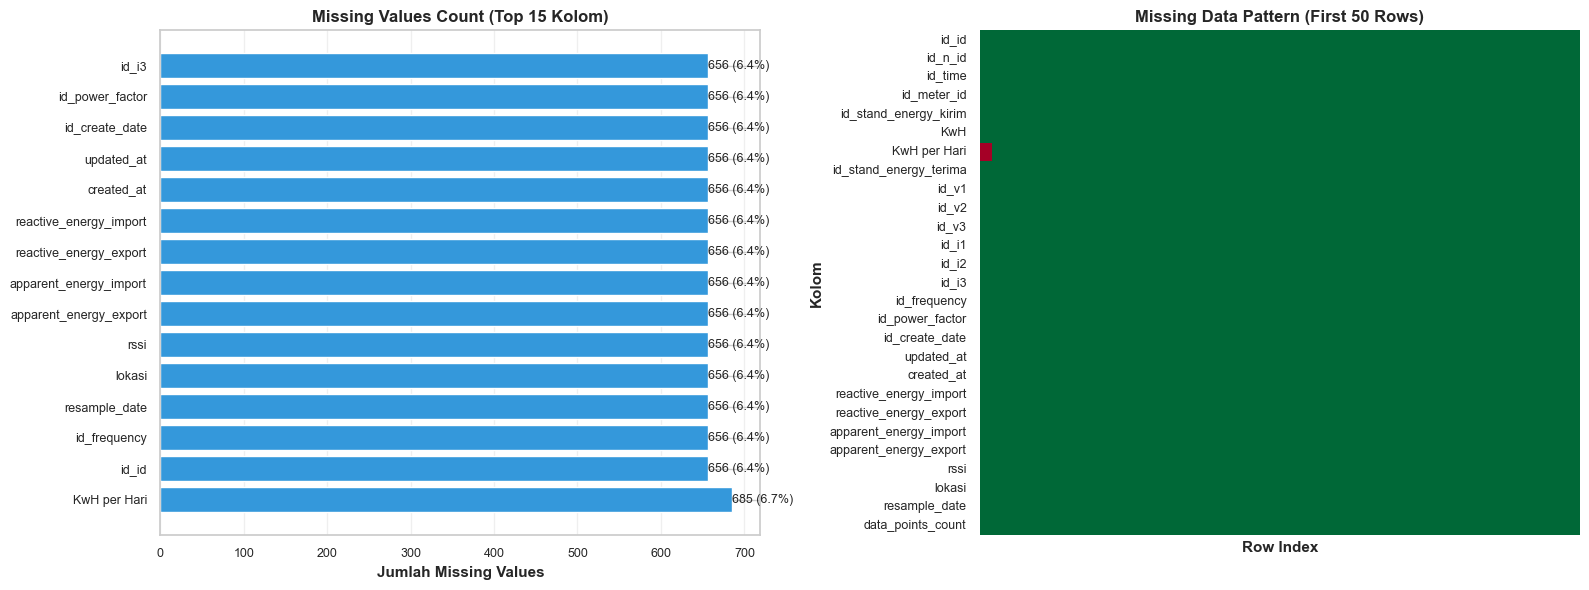

✅ Visualisasi selesai!



In [ ]:
# ==========================================
# 2.6 VISUALISASI MISSING VALUES
# ==========================================

print("\n📊 VISUALISASI MISSING VALUES")
print("=" * 80)

# Hanya visualisasi jika ada missing values
if len(missing_data_filtered) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Bar chart - Missing Count
    ax1 = axes[0]
    missing_data_filtered_top = missing_data_filtered.head(15)  # Top 15
    colors = ['#e74c3c' if x >= 90 else '#e67e22' if x >= 50 else '#f39c12' if x >= 10 else '#3498db' 
              for x in missing_data_filtered_top['Missing_Pct']]
    
    ax1.barh(range(len(missing_data_filtered_top)), missing_data_filtered_top['Missing_Count'], color=colors)
    ax1.set_yticks(range(len(missing_data_filtered_top)))
    ax1.set_yticklabels(missing_data_filtered_top['Kolom'])
    ax1.set_xlabel('Jumlah Missing Values', fontsize=11, fontweight='bold')
    ax1.set_title('Missing Values Count (Top 15 Kolom)', fontsize=12, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)
    
    # Tambahkan value labels
    for i, v in enumerate(missing_data_filtered_top['Missing_Count']):
        ax1.text(v + 0.1, i, f"{v} ({missing_data_filtered_top['Missing_Pct'].iloc[i]:.1f}%)", 
                va='center', fontsize=9)
    
    # Plot 2: Heatmap - Missing Pattern (sample rows)
    ax2 = axes[1]
    sample_size = min(50, len(df))  # Max 50 rows untuk readability
    missing_matrix = df.head(sample_size).isnull().T
    
    sns.heatmap(missing_matrix, cmap='RdYlGn_r', cbar=False, ax=ax2, 
                yticklabels=True, xticklabels=False)
    ax2.set_title(f'Missing Data Pattern (First {sample_size} Rows)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Row Index', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Kolom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Visualisasi selesai!")
else:
    print("ℹ️  Tidak ada missing values untuk divisualisasikan")

print("\n" + "=" * 80)

In [ ]:
# ==========================================
# 2.7 DROP KOLOM YANG TIDAK BERGUNA
# ==========================================

print("\n🗑️  DROPPING KOLOM YANG TIDAK BERGUNA")
print("=" * 80)

# Identifikasi kolom yang akan di-drop
cols_to_drop = []

# 1. Kolom dengan 100% missing values
critical_missing = missing_data[missing_data['Missing_Pct'] == 100]['Kolom'].tolist()
cols_to_drop.extend(critical_missing)

# 2. Kolom yang >95% missing dan tidak penting untuk analisis
high_missing = missing_data[missing_data['Missing_Pct'] >= 95]['Kolom'].tolist()
cols_to_drop.extend([col for col in high_missing if col not in cols_to_drop])

# 3. Kolom duplikat atau tidak perlu (contoh: id_id bisa jadi redundan dengan index)
# Uncomment jika perlu:
# redundant_cols = ['id_id', 'id_n_id']  
# cols_to_drop.extend([col for col in redundant_cols if col in df.columns and col not in cols_to_drop])

# Remove duplicates
cols_to_drop = list(set(cols_to_drop))

if len(cols_to_drop) > 0:
    print(f"📋 Kolom yang akan di-drop ({len(cols_to_drop)}):")
    for col in cols_to_drop:
        missing_pct = missing_data[missing_data['Kolom'] == col]['Missing_Pct'].values[0]
        print(f"   • {col:40s} ({missing_pct:.1f}% missing)")
    
    # Drop kolom
    df = df.drop(columns=cols_to_drop)
    print(f"\n✅ {len(cols_to_drop)} kolom berhasil dihapus!")
else:
    print("✅ Tidak ada kolom yang perlu di-drop")

print("\n" + "=" * 80)


🗑️  DROPPING KOLOM YANG TIDAK BERGUNA
✅ Tidak ada kolom yang perlu di-drop



In [ ]:
# ==========================================
# 2.8 HANDLING MISSING VALUES STRATEGIS
# ==========================================

print("\n🔧 HANDLING MISSING VALUES PADA KOLOM PENTING")
print("=" * 80)

# Strategi berbeda untuk kolom berbeda
handling_strategy = {
    'id_neutral_current': 'fill_zero',  # Jika missing, asumsikan 0
    'id_daya_aktif_plus': 'forward_fill',  # Forward fill untuk power
    'id_daya_aktif_minus': 'fill_zero',  # Jika missing, asumsikan 0
    'rssi': 'keep_nan',  # Keep NaN, bukan parameter kritis
    'lokasi': 'fill_unknown',  # Fill dengan 'Unknown'
}

for col, strategy in handling_strategy.items():
    if col in df.columns:
        missing_before = df[col].isnull().sum()
        
        if missing_before > 0:
            if strategy == 'fill_zero':
                df[col] = df[col].fillna(0)
                print(f"   ✅ {col:30s} → {missing_before} NaN diisi dengan 0")
                
            elif strategy == 'forward_fill':
                df[col] = df[col].fillna(method='ffill')
                print(f"   ✅ {col:30s} → {missing_before} NaN diisi dengan forward fill")
                
            elif strategy == 'fill_unknown':
                df[col] = df[col].fillna('Unknown')
                print(f"   ✅ {col:30s} → {missing_before} NaN diisi dengan 'Unknown'")
                
            elif strategy == 'keep_nan':
                print(f"   ℹ️  {col:30s} → {missing_before} NaN dipertahankan (not critical)")

print("\n" + "=" * 80)


🔧 HANDLING MISSING VALUES PADA KOLOM PENTING
   ℹ️  rssi                           → 656 NaN dipertahankan (not critical)
   ✅ lokasi                         → 656 NaN diisi dengan 'Unknown'



In [ ]:
# ==========================================
# 2.9 SUMMARY SETELAH PEMBERSIHAN
# ==========================================

print("\n📊 SUMMARY PEMBERSIHAN DATA")
print("=" * 80)

print("\n🔹 PERBANDINGAN DIMENSI:")
print(f"   SEBELUM: {df_original.shape[0]:,} baris × {df_original.shape[1]} kolom = {df_original.shape[0] * df_original.shape[1]:,} data points")
print(f"   SESUDAH: {df.shape[0]:,} baris × {df.shape[1]} kolom = {df.shape[0] * df.shape[1]:,} data points")
print(f"   SELISIH: {df_original.shape[1] - df.shape[1]} kolom dihapus")

print("\n🔹 KUALITAS DATA:")
total_cells = df.shape[0] * df.shape[1]
missing_cells = df.isnull().sum().sum()
completeness = ((total_cells - missing_cells) / total_cells * 100)

print(f"   Total Data Cells    : {total_cells:,}")
print(f"   Missing Cells       : {missing_cells:,}")
print(f"   Completeness Rate   : {completeness:.2f}%")

print("\n🔹 TIPE DATA:")
dtype_counts = df.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"   {str(dtype):20s}: {count} kolom")

print("\n" + "=" * 80)

# Display info final
print("\n📋 STRUKTUR DATA FINAL:")
df.info()


📊 SUMMARY PEMBERSIHAN DATA

🔹 PERBANDINGAN DIMENSI:
   SEBELUM: 10,301 baris × 27 kolom = 278,127 data points
   SESUDAH: 10,301 baris × 27 kolom = 278,127 data points
   SELISIH: 0 kolom dihapus

🔹 KUALITAS DATA:
   Total Data Cells    : 278,127
   Missing Cells       : 17,085
   Completeness Rate   : 93.86%

🔹 TIPE DATA:
   float64             : 21 kolom
   object              : 6 kolom


📋 STRUKTUR DATA FINAL:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10301 entries, 0 to 10300
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_id                   9645 non-null   float64
 1   id_n_id                 9645 non-null   float64
 2   id_time                 9645 non-null   object 
 3   id_meter_id             9645 non-null   float64
 4   id_stand_energy_kirim   9645 non-null   float64
 5   KwH                     9645 non-null   float64
 6   KwH per Hari            9616 non-null   floa

In [ ]:
# ==========================================
# 2.10 PREVIEW DATA SETELAH DIBERSIHKAN
# ==========================================

print("\n📋 PREVIEW DATA SETELAH DIBERSIHKAN")
print("=" * 80)
display(df.head(10))

print("\n📊 STATISTIK DESKRIPTIF (NUMERIK ONLY)")
print("=" * 80)
display(df.describe().T)


📋 PREVIEW DATA SETELAH DIBERSIHKAN


,id_id,id_n_id,id_time,id_meter_id,id_stand_energy_kirim,KwH,KwH per Hari,id_stand_energy_terima,id_v1,id_v2,id_v3,id_i1,id_i2,id_i3,id_frequency,id_power_factor,id_create_date,updated_at,created_at,reactive_energy_import,reactive_energy_export,apparent_energy_import,apparent_energy_export,rssi,lokasi,resample_date,data_points_count
0,605002.0,67.0,2024-01-01,2.51e+08,4.68e+07,4683.21,NaN,0.0,227.12,227.58,229.25,0.98,1.84,3.83,50.00,0.86,1/1/2024 22:25,1/1/2024 22:25,1/1/2024 22:25,9.76e+06,1.36e+06,5.13e+07,0.0,-110.60,97.0,1/1/2024,1.0
1,609728.0,67.0,2024-01-02,2.51e+08,4.74e+07,4736.55,53.34,0.0,225.54,225.69,227.79,1.27,10.69,5.24,50.00,0.95,1/2/2024 23:50,1/2/2024 23:50,1/2/2024 23:50,9.88e+06,1.37e+06,5.19e+07,0.0,-117.21,97.0,1/2/2024,1.0
2,612415.0,67.0,2024-01-03,2.51e+08,4.80e+07,4804.62,68.07,0.0,227.68,228.01,229.79,1.20,6.77,4.61,50.01,0.93,1/3/2024 23:55,1/3/2024 23:55,1/3/2024 23:55,1.00e+07,1.38e+06,5.26e+07,0.0,-119.73,97.0,1/3/2024,1.0
3,615949.0,67.0,2024-01-04,2.51e+08,4.86e+07,4856.85,52.23,0.0,226.45,226.95,228.42,1.00,4.10,4.59,50.00,0.91,1/4/2024 23:55,1/4/2024 23:55,1/4/2024 23:55,1.01e+07,1.39e+06,5.32e+07,0.0,-119.42,97.0,1/4/2024,1.0
4,619405.0,67.0,2024-01-05,2.51e+08,4.89e+07,4891.98,35.13,0.0,226.51,227.01,228.38,1.10,1.84,4.50,50.01,0.87,1/5/2024 20:50,1/5/2024 20:50,1/5/2024 20:50,1.02e+07,1.40e+06,5.36e+07,0.0,-117.79,97.0,1/5/2024,1.0
5,625154.0,67.0,2024-01-06,2.51e+08,4.94e+07,4942.60,50.63,0.0,228.43,228.92,230.43,1.88,2.25,4.08,50.03,0.89,1/6/2024 22:25,1/6/2024 22:25,1/6/2024 22:25,1.04e+07,1.41e+06,5.41e+07,0.0,-119.57,97.0,1/6/2024,1.0
6,627691.0,67.0,2024-01-07,2.51e+08,4.97e+07,4968.89,26.29,0.0,227.52,227.95,229.50,1.63,1.35,3.81,50.01,0.86,1/7/2024 23:55,1/7/2024 23:55,1/7/2024 23:55,1.04e+07,1.42e+06,5.44e+07,0.0,-119.74,97.0,1/7/2024,1.0
7,630410.0,67.0,2024-01-08,2.51e+08,5.00e+07,5003.19,34.30,0.0,226.60,227.03,228.58,1.75,2.87,4.42,50.02,0.89,1/8/2024 23:55,1/8/2024 23:55,1/8/2024 23:55,1.05e+07,1.43e+06,5.48e+07,0.0,-119.48,97.0,1/8/2024,1.0
8,634320.0,67.0,2024-01-09,2.51e+08,5.04e+07,5036.28,33.10,0.0,226.48,226.95,228.54,1.26,3.97,4.35,50.01,0.89,1/9/2024 20:55,1/9/2024 20:55,1/9/2024 20:55,1.06e+07,1.44e+06,5.52e+07,0.0,-120.34,97.0,1/9/2024,1.0
9,639005.0,67.0,2024-01-10,2.51e+08,5.11e+07,5106.66,70.37,0.0,228.70,228.98,230.69,1.00,2.58,4.25,50.02,0.89,1/10/2024 23:55,1/10/2024 23:55,1/10/2024 23:55,1.08e+07,1.46e+06,5.60e+07,0.0,-118.60,97.0,1/10/2024,1.0



📊 STATISTIK DESKRIPTIF (NUMERIK ONLY)


,count,mean,std,min,25%,50%,75%,max
id_id,9645.0,1.80e+06,7.91e+05,6.05e+05,1.07e+06,1.69e+06,2.67e+06,3.11e+06
id_n_id,9645.0,3.09e+01,1.34e+01,1.10e+01,2.00e+01,3.00e+01,3.90e+01,6.70e+01
id_meter_id,9645.0,2.51e+08,5.60e+01,2.51e+08,2.51e+08,2.51e+08,2.51e+08,2.51e+08
id_stand_energy_kirim,9645.0,9.91e+07,1.17e+08,2.68e+06,3.16e+07,6.52e+07,1.27e+08,1.27e+09
KwH,9645.0,9.91e+03,1.17e+04,2.68e+02,3.16e+03,6.52e+03,1.27e+04,1.27e+05
KwH per Hari,9616.0,3.92e+01,8.14e+01,0.00e+00,7.93e+00,2.47e+01,4.87e+01,2.21e+03
id_stand_energy_terima,9645.0,1.29e+03,4.95e+03,0.00e+00,0.00e+00,0.00e+00,0.00e+00,2.52e+04
id_v1,9645.0,2.27e+02,1.32e+00,2.18e+02,2.26e+02,2.27e+02,2.28e+02,2.32e+02
id_v2,9645.0,2.27e+02,1.44e+00,2.19e+02,2.27e+02,2.28e+02,2.28e+02,2.33e+02
id_v3,9645.0,2.29e+02,1.37e+00,2.20e+02,2.28e+02,2.29e+02,2.30e+02,2.32e+02


In [ ]:
# ==========================================
# 3.1 PEMETAAN METER KE KATEGORI BEBAN
# ==========================================

print("=" * 80)
print("🗺️  PEMETAAN METER KE KATEGORI BEBAN")
print("=" * 80)

# --- METER MAP BERDASARKAN DIAGRAM ELEKTRIKAL ---
# Lengkapi sesuai dengan data 500 baris Anda

meter_map = {
    # ========== MDP 3.1 WITEL ==========
    # HVAC - Chiller & AHU
    251400177: {'kategori_beban': 'CHILLER', 'group_beban': 'HVAC', 'lokasi_panel': 'MDP_3.1_WITEL'},
    251400251: {'kategori_beban': 'AHU_L1_WITEL', 'group_beban': 'HVAC', 'lokasi_panel': 'MDP_3.1_WITEL'},
    251400321: {'kategori_beban': 'AHU_L2_WITEL', 'group_beban': 'HVAC', 'lokasi_panel': 'MDP_3.1_WITEL'},
    251400387: {'kategori_beban': 'AHU_L3_WITEL', 'group_beban': 'HVAC', 'lokasi_panel': 'MDP_3.1_WITEL'},
    251400373: {'kategori_beban': 'AHU_L4_WITEL', 'group_beban': 'HVAC', 'lokasi_panel': 'MDP_3.1_WITEL'},
    251400316: {'kategori_beban': 'AHU_L5_WITEL', 'group_beban': 'HVAC', 'lokasi_panel': 'MDP_3.1_WITEL'},
    251400276: {'kategori_beban': 'AHU_L6_WITEL', 'group_beban': 'HVAC', 'lokasi_panel': 'MDP_3.1_WITEL'},
    251400382: {'kategori_beban': 'AHU_L7_WITEL', 'group_beban': 'HVAC', 'lokasi_panel': 'MDP_3.1_WITEL'},
    251400385: {'kategori_beban': 'AHU_L8_WITEL', 'group_beban': 'HVAC', 'lokasi_panel': 'MDP_3.1_WITEL'},
    251400271: {'kategori_beban': 'DBT_AC', 'group_beban': 'HVAC', 'lokasi_panel': 'MDP_3.1_WITEL'},
    
    # IT Equipment
    251400372: {'kategori_beban': 'SERVER_NOC', 'group_beban': 'IT', 'lokasi_panel': 'MDP_3.1_WITEL'},
    
    # Mekanikal - Lift
    251400184: {'kategori_beban': 'LIFT_WITEL', 'group_beban': 'MEKANIKAL', 'lokasi_panel': 'MDP_3.1_WITEL'},
    
    # Power Distribution - SDP
    251400383: {'kategori_beban': 'SDP_L1_WITEL', 'group_beban': 'POWER_DIST', 'lokasi_panel': 'MDP_3.1_WITEL'},
    251400322: {'kategori_beban': 'SDP_L2_WITEL', 'group_beban': 'POWER_DIST', 'lokasi_panel': 'MDP_3.1_WITEL'},
    251400320: {'kategori_beban': 'SDP_L3_WITEL', 'group_beban': 'POWER_DIST', 'lokasi_panel': 'MDP_3.1_WITEL'},
    251400277: {'kategori_beban': 'SDP_L4_WITEL', 'group_beban': 'POWER_DIST', 'lokasi_panel': 'MDP_3.1_WITEL'},
    251400381: {'kategori_beban': 'SDP_L5_WITEL', 'group_beban': 'POWER_DIST', 'lokasi_panel': 'MDP_3.1_WITEL'},
    251400384: {'kategori_beban': 'SDP_L6_WITEL', 'group_beban': 'POWER_DIST', 'lokasi_panel': 'MDP_3.1_WITEL'},
    251400279: {'kategori_beban': 'SDP_L7_WITEL', 'group_beban': 'POWER_DIST', 'lokasi_panel': 'MDP_3.1_WITEL'},
    251400278: {'kategori_beban': 'SDP_L8_WITEL', 'group_beban': 'POWER_DIST', 'lokasi_panel': 'MDP_3.1_WITEL'},
    
    # ========== MDP 3.2 OPMC ==========
    # HVAC - AHU
    251400247: {'kategori_beban': 'AHU_L2_OPMC', 'group_beban': 'HVAC', 'lokasi_panel': 'MDP_3.2_OPMC'},
    251400318: {'kategori_beban': 'AHU_L3_OPMC', 'group_beban': 'HVAC', 'lokasi_panel': 'MDP_3.2_OPMC'},
    251400244: {'kategori_beban': 'AHU_L4_OPMC', 'group_beban': 'HVAC', 'lokasi_panel': 'MDP_3.2_OPMC'},
    251400281: {'kategori_beban': 'AHU_L5_OPMC', 'group_beban': 'HVAC', 'lokasi_panel': 'MDP_3.2_OPMC'},
    251400270: {'kategori_beban': 'AHU_L6_OPMC', 'group_beban': 'HVAC', 'lokasi_panel': 'MDP_3.2_OPMC'},
    
    # IT Equipment
    251400280: {'kategori_beban': 'PANEL_SISCA_L6', 'group_beban': 'IT', 'lokasi_panel': 'MDP_3.2_OPMC'},
    
    # Mekanikal - Lift
    251400378: {'kategori_beban': 'LIFT_OPMC', 'group_beban': 'MEKANIKAL', 'lokasi_panel': 'MDP_3.2_OPMC'},
    
    # Power Distribution - SDP
    251400282: {'kategori_beban': 'SDP_L1_OPMC', 'group_beban': 'POWER_DIST', 'lokasi_panel': 'MDP_3.2_OPMC'},
    251400249: {'kategori_beban': 'SDP_L2_OPMC', 'group_beban': 'POWER_DIST', 'lokasi_panel': 'MDP_3.2_OPMC'},
    251400248: {'kategori_beban': 'SDP_L3_OPMC', 'group_beban': 'POWER_DIST', 'lokasi_panel': 'MDP_3.2_OPMC'},
    251400319: {'kategori_beban': 'SDP_L4_OPMC', 'group_beban': 'POWER_DIST', 'lokasi_panel': 'MDP_3.2_OPMC'},
    251400323: {'kategori_beban': 'SDP_L5_OPMC', 'group_beban': 'POWER_DIST', 'lokasi_panel': 'MDP_3.2_OPMC'},
    251400386: {'kategori_beban': 'SDP_L6_OPMC', 'group_beban': 'POWER_DIST', 'lokasi_panel': 'MDP_3.2_OPMC'},
    
    # ========== METER DARI SAMPEL (Unknown) ==========
    251400179: {'kategori_beban': 'METER_179', 'group_beban': 'UNIDENTIFIED', 'lokasi_panel': 'UNKNOWN'},
    251400172: {'kategori_beban': 'METER_172', 'group_beban': 'UNIDENTIFIED', 'lokasi_panel': 'UNKNOWN'},
    251400182: {'kategori_beban': 'METER_182', 'group_beban': 'UNIDENTIFIED', 'lokasi_panel': 'UNKNOWN'},
    251400178: {'kategori_beban': 'METER_178', 'group_beban': 'UNIDENTIFIED', 'lokasi_panel': 'UNKNOWN'},
    251400181: {'kategori_beban': 'METER_181', 'group_beban': 'UNIDENTIFIED', 'lokasi_panel': 'UNKNOWN'},
}

print(f"\n✅ Meter map berisi {len(meter_map)} meter yang teridentifikasi\n")

# Konversi map ke DataFrame
map_df = pd.DataFrame.from_dict(meter_map, orient='index').reset_index()
map_df = map_df.rename(columns={'index': 'id_meter_id'})

print("📋 PREVIEW METER MAP:")
display(map_df.head(10))

🗺️  PEMETAAN METER KE KATEGORI BEBAN

✅ Meter map berisi 38 meter yang teridentifikasi

📋 PREVIEW METER MAP:


,id_meter_id,kategori_beban,group_beban,lokasi_panel
0,251400177,CHILLER,HVAC,MDP_3.1_WITEL
1,251400251,AHU_L1_WITEL,HVAC,MDP_3.1_WITEL
2,251400321,AHU_L2_WITEL,HVAC,MDP_3.1_WITEL
3,251400387,AHU_L3_WITEL,HVAC,MDP_3.1_WITEL
4,251400373,AHU_L4_WITEL,HVAC,MDP_3.1_WITEL
5,251400316,AHU_L5_WITEL,HVAC,MDP_3.1_WITEL
6,251400276,AHU_L6_WITEL,HVAC,MDP_3.1_WITEL
7,251400382,AHU_L7_WITEL,HVAC,MDP_3.1_WITEL
8,251400385,AHU_L8_WITEL,HVAC,MDP_3.1_WITEL
9,251400271,DBT_AC,HVAC,MDP_3.1_WITEL


In [ ]:
# ==========================================
# 3.2 VALIDASI COVERAGE METER MAP
# ==========================================

print("\n" + "=" * 80)
print("🔍 VALIDASI COVERAGE METER MAP")
print("=" * 80)

# Identifikasi meter unik di data
unique_meters_in_data = df['id_meter_id'].unique()
unique_meters_in_map = map_df['id_meter_id'].unique()

print(f"\n📊 SUMMARY:")
print(f"   Meter unik di DATA     : {len(unique_meters_in_data)}")
print(f"   Meter unik di MAP      : {len(unique_meters_in_map)}")

# Meter yang ada di data tapi tidak di map
unmapped_meters = set(unique_meters_in_data) - set(unique_meters_in_map)
if len(unmapped_meters) > 0:
    print(f"\n⚠️  UNMAPPED METERS ({len(unmapped_meters)}):")
    for meter in unmapped_meters:
        count = len(df[df['id_meter_id'] == meter])
        pct = (count / len(df) * 100)
        print(f"      • Meter {meter}: {count} records ({pct:.1f}% dari total data)")
    print(f"\n   ⚡ ACTION: Tambahkan meter ini ke dalam meter_map dictionary!")
else:
    print(f"\n✅ Semua meter di data sudah termapping!")

# Meter yang ada di map tapi tidak di data
unused_meters = set(unique_meters_in_map) - set(unique_meters_in_data)
if len(unused_meters) > 0:
    print(f"\nℹ️  UNUSED METERS di map ({len(unused_meters)}):")
    print(f"   Meter-meter ini ada di map tapi tidak ada di dataset sampel")
    print(f"   (Normal jika menggunakan data sampel 25 baris)")

print("\n" + "=" * 80)


🔍 VALIDASI COVERAGE METER MAP

📊 SUMMARY:
   Meter unik di DATA     : 30
   Meter unik di MAP      : 38

⚠️  UNMAPPED METERS (1):
      • Meter nan: 0 records (0.0% dari total data)

   ⚡ ACTION: Tambahkan meter ini ke dalam meter_map dictionary!

ℹ️  UNUSED METERS di map (9):
   Meter-meter ini ada di map tapi tidak ada di dataset sampel
   (Normal jika menggunakan data sampel 25 baris)



In [ ]:
# ==========================================
# 3.3 MERGE DATA DENGAN METER MAP
# ==========================================

print("\n🔗 MERGING DATA DENGAN METER MAP")
print("=" * 80)

# Backup sebelum merge
df_before_merge = df.copy()

# Merge
df = pd.merge(df, map_df, on='id_meter_id', how='left')

# Handle unmapped meters
unmapped_count = df['kategori_beban'].isnull().sum()

if unmapped_count > 0:
    print(f"\n⚠️  {unmapped_count} records dengan meter yang tidak termapping")
    print(f"   Mengisi dengan kategori 'UNIDENTIFIED'")
    
    df['kategori_beban'] = df['kategori_beban'].fillna('UNIDENTIFIED')
    df['group_beban'] = df['group_beban'].fillna('UNIDENTIFIED')
    df['lokasi_panel'] = df['lokasi_panel'].fillna('UNKNOWN')

print(f"\n✅ Merge selesai!")
print(f"   Kolom baru ditambahkan: kategori_beban, group_beban, lokasi_panel")

# Summary distribusi group beban
print(f"\n📊 DISTRIBUSI GROUP BEBAN:")
group_dist = df['group_beban'].value_counts()
for group, count in group_dist.items():
    pct = (count / len(df) * 100)
    print(f"   {group:20s}: {count:4d} records ({pct:5.1f}%)")

print("\n" + "=" * 80)


🔗 MERGING DATA DENGAN METER MAP

⚠️  656 records dengan meter yang tidak termapping
   Mengisi dengan kategori 'UNIDENTIFIED'

✅ Merge selesai!
   Kolom baru ditambahkan: kategori_beban, group_beban, lokasi_panel

📊 DISTRIBUSI GROUP BEBAN:
   POWER_DIST          : 4793 records ( 46.5%)
   HVAC                : 4509 records ( 43.8%)
   UNIDENTIFIED        :  656 records (  6.4%)
   MEKANIKAL           :  343 records (  3.3%)



In [ ]:
# ==========================================
# 3.4 PERHITUNGAN KONSUMSI ENERGI (DELTA)
# ==========================================

print("\n⚡ PERHITUNGAN KONSUMSI ENERGI (DELTA METHOD)")
print("=" * 80)

# STEP 1: Pastikan data terurut dengan benar
print("\n📐 STEP 1: Sorting data...")
df = df.sort_values(by=['id_meter_id', 'id_time']).reset_index(drop=True)
print(f"   ✅ Data diurutkan berdasarkan [id_meter_id, id_time]")

# STEP 2: Hitung delta (konsumsi) per meter
print(f"\n🔢 STEP 2: Menghitung delta energi...")
df['energy_consumed_kwh'] = df.groupby('id_meter_id')['id_stand_energy_kirim'].diff()

# Hitung berapa yang berhasil
valid_consumption = df['energy_consumed_kwh'].notna().sum()
print(f"   ✅ {valid_consumption} dari {len(df)} records berhasil dihitung")

# STEP 3: Handle edge cases
print(f"\n🛠️  STEP 3: Handling edge cases...")

# 3.1 - First reading per meter (NaN)
first_readings = df['energy_consumed_kwh'].isnull().sum()
if first_readings > 0:
    print(f"   • {first_readings} first readings (NaN) → diisi dengan 0")
    df['energy_consumed_kwh'] = df['energy_consumed_kwh'].fillna(0)

# 3.2 - Negative values (meter reset)
negative_count = (df['energy_consumed_kwh'] < 0).sum()
if negative_count > 0:
    print(f"   • {negative_count} negative values (meter reset detected)")
    print(f"     → Menampilkan detail untuk investigasi...")
    
    negative_data = df[df['energy_consumed_kwh'] < 0][
        ['id_time', 'id_meter_id', 'kategori_beban', 'id_stand_energy_kirim', 'energy_consumed_kwh']
    ].head(10)
    display(negative_data)
    
    # Option: Set negative to 0 or keep for analysis
    print(f"\n   ⚠️  ACTION DIPERLUKAN:")
    print(f"      - Opsi 1: Set negative ke 0 (asumsikan error)")
    print(f"      - Opsi 2: Keep untuk analisis anomali")
    print(f"      - Untuk tutorial ini: KEEP (tidak diubah)")

# 3.3 - Extreme outliers (>1000 kWh dalam 5 menit? Tidak masuk akal)
outlier_threshold = 5000  # kWh
extreme_outliers = (df['energy_consumed_kwh'] > outlier_threshold).sum()
if extreme_outliers > 0:
    print(f"   • {extreme_outliers} extreme outliers (>{outlier_threshold} kWh)")
    print(f"     → Menampilkan untuk investigasi...")
    
    outlier_data = df[df['energy_consumed_kwh'] > outlier_threshold][
        ['id_time', 'id_meter_id', 'kategori_beban', 'energy_consumed_kwh']
    ].head(10)
    display(outlier_data)

print("\n✅ Perhitungan konsumsi energi selesai!")
print("=" * 80)


⚡ PERHITUNGAN KONSUMSI ENERGI (DELTA METHOD)

📐 STEP 1: Sorting data...
   ✅ Data diurutkan berdasarkan [id_meter_id, id_time]

🔢 STEP 2: Menghitung delta energi...
   ✅ 9616 dari 10301 records berhasil dihitung

🛠️  STEP 3: Handling edge cases...
   • 685 first readings (NaN) → diisi dengan 0
   • 8647 extreme outliers (>5000 kWh)
     → Menampilkan untuk investigasi...


,id_time,id_meter_id,kategori_beban,energy_consumed_kwh
1,2024-01-02,2.51e+08,CHILLER,5.85e+06
2,2024-01-03,2.51e+08,CHILLER,1.39e+07
3,2024-01-04,2.51e+08,CHILLER,1.20e+07
4,2024-01-05,2.51e+08,CHILLER,1.24e+07
5,2024-01-06,2.51e+08,CHILLER,6.55e+06
6,2024-01-07,2.51e+08,CHILLER,3.45e+05
7,2024-01-08,2.51e+08,CHILLER,8.16e+06
8,2024-01-09,2.51e+08,CHILLER,1.30e+07
9,2024-01-10,2.51e+08,CHILLER,1.39e+07
10,2024-01-11,2.51e+08,CHILLER,1.10e+07



✅ Perhitungan konsumsi energi selesai!


In [ ]:
# ==========================================
# 3.5 EKSTRAKSI FITUR TEMPORAL
# ==========================================

print("\n📅 EKSTRAKSI FITUR TEMPORAL (TIME-BASED FEATURES)")
print("=" * 80)

if pd.api.types.is_datetime64_any_dtype(df['id_time']):
    print("\n⏰ Membuat fitur temporal dari kolom 'id_time'...\n")
    
    # Date components
    df['year'] = df['id_time'].dt.year
    df['month'] = df['id_time'].dt.month
    df['day'] = df['id_time'].dt.day
    df['hour'] = df['id_time'].dt.hour
    df['minute'] = df['id_time'].dt.minute
    df['dayofweek'] = df['id_time'].dt.dayofweek  # 0=Monday, 6=Sunday
    df['dayname'] = df['id_time'].dt.day_name()
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
    
    # Time of day categorization
    def categorize_time_of_day(hour):
        if 6 <= hour < 12:
            return 'Pagi'
        elif 12 <= hour < 18:
            return 'Siang'
        elif 18 <= hour < 22:
            return 'Malam'
        else:
            return 'Dini_Hari'
    
    df['time_of_day'] = df['hour'].apply(categorize_time_of_day)
    
    # Business hours
    df['is_business_hour'] = ((df['hour'] >= 8) & (df['hour'] < 17) & (df['is_weekend'] == 0)).astype(int)
    
    # Time interval calculation (minutes between readings)
    df['time_interval_minutes'] = df.groupby('id_meter_id')['id_time'].diff().dt.total_seconds() / 60
    
    print("✅ Fitur temporal berhasil dibuat:")
    temporal_features = ['year', 'month', 'day', 'hour', 'minute', 'dayofweek', 'dayname', 
                         'is_weekend', 'time_of_day', 'is_business_hour', 'time_interval_minutes']
    for feat in temporal_features:
        print(f"   • {feat}")
    
    # Summary
    print(f"\n📊 SUMMARY TEMPORAL:")
    print(f"   Periode data      : {df['id_time'].min()} s/d {df['id_time'].max()}")
    print(f"   Durasi total      : {(df['id_time'].max() - df['id_time'].min()).days} hari")
    print(f"   Weekend records   : {df['is_weekend'].sum()} ({df['is_weekend'].sum()/len(df)*100:.1f}%)")
    print(f"   Business hours    : {df['is_business_hour'].sum()} ({df['is_business_hour'].sum()/len(df)*100:.1f}%)")
else:
    print("⚠️  Kolom 'id_time' bukan datetime. Skip ekstraksi temporal.")

print("\n" + "=" * 80)


📅 EKSTRAKSI FITUR TEMPORAL (TIME-BASED FEATURES)
⚠️  Kolom 'id_time' bukan datetime. Skip ekstraksi temporal.



In [ ]:
# ==========================================
# 3.6 PERHITUNGAN METRIK POWER TAMBAHAN
# ==========================================

print("\n⚡ PERHITUNGAN METRIK POWER TAMBAHAN")
print("=" * 80)

print("\n🔧 Membuat metrik power tambahan...\n")

# 1. Average Voltage per phase
df['voltage_avg'] = (df['id_v1'] + df['id_v2'] + df['id_v3']) / 3

# 2. Average Current per phase
df['current_avg'] = (df['id_i1'] + df['id_i2'] + df['id_i3']) / 3

# 3. Voltage imbalance (max deviation from average)
df['voltage_imbalance_pct'] = (
    df[['id_v1', 'id_v2', 'id_v3']].max(axis=1) - 
    df[['id_v1', 'id_v2', 'id_v3']].min(axis=1)
) / df['voltage_avg'] * 100

# 4. Current imbalance (max deviation from average)
df['current_imbalance_pct'] = (
    df[['id_i1', 'id_i2', 'id_i3']].max(axis=1) - 
    df[['id_i1', 'id_i2', 'id_i3']].min(axis=1)
) / df['current_avg'].replace(0, np.nan) * 100

# 5. Total Apparent Power (VA) - 3 phase
# S = sqrt(3) × V_line × I_line
df['apparent_power_kva'] = np.sqrt(3) * (df['voltage_avg'] / 1000) * df['current_avg']

# 6. Total Active Power (W) - estimated
# P = S × PF
df['active_power_kw'] = df['apparent_power_kva'] * df['id_power_factor']

# 7. Reactive Power (VAR) - estimated
# Q = sqrt(S² - P²)
df['reactive_power_kvar'] = np.sqrt(
    np.maximum(df['apparent_power_kva']**2 - df['active_power_kw']**2, 0)
)

# 8. Power quality indicator (low PF = poor quality)
df['power_quality'] = pd.cut(
    df['id_power_factor'], 
    bins=[0, 0.85, 0.95, 1.0], 
    labels=['Poor', 'Fair', 'Good']
)

# 9. Energy consumption rate (kW per interval)
# Handle division by zero
df['consumption_rate_kw'] = df['energy_consumed_kwh'] / (
    df['time_interval_minutes'].replace(0, np.nan) / 60
)

print("✅ Metrik power tambahan berhasil dibuat:")
power_metrics = [
    'voltage_avg', 'current_avg', 'voltage_imbalance_pct', 'current_imbalance_pct',
    'apparent_power_kva', 'active_power_kw', 'reactive_power_kvar', 
    'power_quality', 'consumption_rate_kw'
]
for metric in power_metrics:
    print(f"   • {metric}")

# Summary statistik
print(f"\n📊 STATISTIK POWER METRICS:")
summary_cols = ['voltage_avg', 'current_avg', 'apparent_power_kva', 
                'active_power_kw', 'id_power_factor']
display(df[summary_cols].describe().T)

print("\n" + "=" * 80)


⚡ PERHITUNGAN METRIK POWER TAMBAHAN

🔧 Membuat metrik power tambahan...



KeyError: 'time_interval_minutes'